In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, log_loss

xa = '/home/santi3223/contest game/IA/obiaprob2/sample_submission.csv'
xb = '/home/santi3223/contest game/IA/obiaprob2/test.csv'
xc = '/home/santi3223/contest game/IA/obiaprob2/train.csv'

ssub = pd.read_csv(xa)
tst = pd.read_csv(xb)
trn = pd.read_csv(xc)

ssub

,id,Status_C,Status_CL,Status_D
0,3,0.333333,0.333333,0.333333
1,5,0.333333,0.333333,0.333333
2,7,0.333333,0.333333,0.333333
3,10,0.333333,0.333333,0.333333
4,11,0.333333,0.333333,0.333333
...,...,...,...,...
121,407,0.333333,0.333333,0.333333
122,410,0.333333,0.333333,0.333333
123,411,0.333333,0.333333,0.333333
124,415,0.333333,0.333333,0.333333


In [2]:
tst

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,3,1012,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
1,5,1504,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
2,7,1832,Placebo,20284,F,N,Y,N,N,1.0,322.0,4.09,52.0,824.0,60.45,213.0,204.0,9.7,3.0
3,10,51,Placebo,25772,F,Y,N,Y,Y,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,4.0
4,11,3762,Placebo,19619,F,N,Y,Y,N,1.4,259.0,4.16,46.0,1104.0,79.05,79.0,258.0,12.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,407,1129,NaN,19724,M,NaN,NaN,NaN,N,1.1,NaN,3.69,NaN,NaN,NaN,NaN,220.0,10.8,3.0
122,410,1072,NaN,14245,F,NaN,NaN,NaN,N,1.5,NaN,3.81,NaN,NaN,NaN,NaN,255.0,10.8,3.0
123,411,1119,NaN,18628,F,NaN,NaN,NaN,N,0.6,NaN,3.57,NaN,NaN,NaN,NaN,286.0,10.6,3.0
124,415,1103,NaN,14245,F,NaN,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0


In [3]:
tst.columns

Index(['id', 'N_Days', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly',
       'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage'],
      dtype='str')

In [5]:
trn

,id,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
3,6,2503,D,Placebo,24201,F,N,Y,N,N,0.8,248.0,3.98,50.0,944.0,93.00,63.0,NaN,11.0,3.0
4,8,2466,D,Placebo,19379,F,N,N,N,N,0.3,280.0,4.00,52.0,4651.2,28.38,189.0,373.0,11.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,412,1097,C,NaN,24472,F,NaN,NaN,NaN,N,1.0,NaN,3.58,NaN,NaN,NaN,NaN,244.0,10.8,3.0
288,413,989,C,NaN,12784,F,NaN,NaN,NaN,N,0.7,NaN,3.23,NaN,NaN,NaN,NaN,312.0,10.8,3.0
289,414,681,D,NaN,24472,F,NaN,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
290,416,1055,C,NaN,20819,F,NaN,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report, accuracy_score, log_loss

# Preprocesamiento: eliminar la columna 'id' y codificar variables categóricas
X = trn.drop(['Status', 'id'], axis=1)  # Características
y = trn['Status']  # Etiqueta objetivo

# Codificar variables categóricas
X = pd.get_dummies(X, drop_first=True)

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# Crear el modelo de Random Forest para clasificación
model = RandomForestClassifier(n_estimators=41, random_state=1)

# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones de probabilidad
y_pred_proba = model.predict_proba(X_test)

# Hacer predicciones de clase
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Calcular log loss
logloss = log_loss(y_test, y_pred_proba)

# Imprimir resultados
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(report)
print(f'Log Loss: {logloss:.10f}')

# Asegúrate de que las columnas de prueba coincidan con las de entrenamiento
tst_features = tst.drop('id', axis=1)  # Eliminar la columna 'id'
tst_features = pd.get_dummies(tst_features, drop_first=True)  # Codificar variables categóricas

# Alinear las columnas de tst_features con las de X_train
tst_features = tst_features.reindex(columns=X.columns, fill_value=0)

# Hacer predicciones en el conjunto de prueba
predicciones_test = model.predict(tst_features)

# Crear un DataFrame para las predicciones
resultados = pd.DataFrame({
    'id': tst['id'],
    'Status_C': (predicciones_test == 'C').astype(float),
    'Status_CL': (predicciones_test == 'CL').astype(float),
    'Status_D': (predicciones_test == 'D').astype(float)
})

# Asegurarse de que las columnas sean de tipo float
resultados['Status_C'] = resultados['Status_C'].astype(float)
resultados['Status_CL'] = resultados['Status_CL'].astype(float)
resultados['Status_D'] = resultados['Status_D'].astype(float)

# Guardar las predicciones en un archivo CSV
resultados.to_csv('predicciones.csv', index=False)

Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

           C       0.85      0.87      0.86        45
          CL       1.00      0.33      0.50         6
           D       0.64      0.73      0.68        22

    accuracy                           0.78        73
   macro avg       0.83      0.64      0.68        73
weighted avg       0.80      0.78      0.77        73

Log Loss: 1.0351248920


In [38]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,id
789,7.2,0.670,0.00,2.2,0.068,10.0,24.0,0.99560,3.42,0.72,11.1,1399
185,10.3,0.440,0.50,4.5,0.107,5.0,13.0,0.99800,3.28,0.83,11.5,327
363,7.5,0.420,0.31,1.6,0.080,15.0,42.0,0.99780,3.31,0.64,9.0,661
887,6.6,0.855,0.02,2.4,0.062,15.0,23.0,0.99627,3.54,0.60,11.0,1557
531,8.5,0.470,0.27,1.9,0.058,18.0,38.0,0.99518,3.16,0.85,11.1,960
...,...,...,...,...,...,...,...,...,...,...,...,...
767,7.3,0.430,0.24,2.5,0.078,27.0,67.0,0.99648,3.60,0.59,11.1,1357
72,7.2,0.415,0.36,2.0,0.081,13.0,45.0,0.99720,3.48,0.64,9.2,137
908,5.4,0.740,0.09,1.7,0.089,16.0,26.0,0.99402,3.67,0.56,11.6,1591
235,9.1,0.520,0.33,1.3,0.070,9.0,30.0,0.99780,3.24,0.60,9.3,428


In [35]:
tst_features

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,id
0,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,3
1,5.6,0.615,0.00,1.6,0.089,16.0,59.0,0.99430,3.58,0.52,9.9,12
2,8.3,0.655,0.12,2.3,0.083,15.0,113.0,0.99660,3.17,0.66,9.8,32
3,7.5,0.490,0.20,2.6,0.332,8.0,14.0,0.99680,3.21,0.90,10.5,42
4,8.1,0.660,0.22,2.2,0.069,9.0,23.0,0.99680,3.30,1.20,10.3,43
...,...,...,...,...,...,...,...,...,...,...,...,...
224,7.0,0.560,0.13,1.6,0.077,25.0,42.0,0.99629,3.34,0.59,9.2,1568
225,6.2,0.700,0.15,5.1,0.076,13.0,27.0,0.99622,3.54,0.60,11.9,1577
226,6.8,0.670,0.15,1.8,0.118,13.0,20.0,0.99540,3.42,0.67,11.3,1578
227,7.5,0.310,0.41,2.4,0.065,34.0,60.0,0.99492,3.34,0.85,11.4,1586


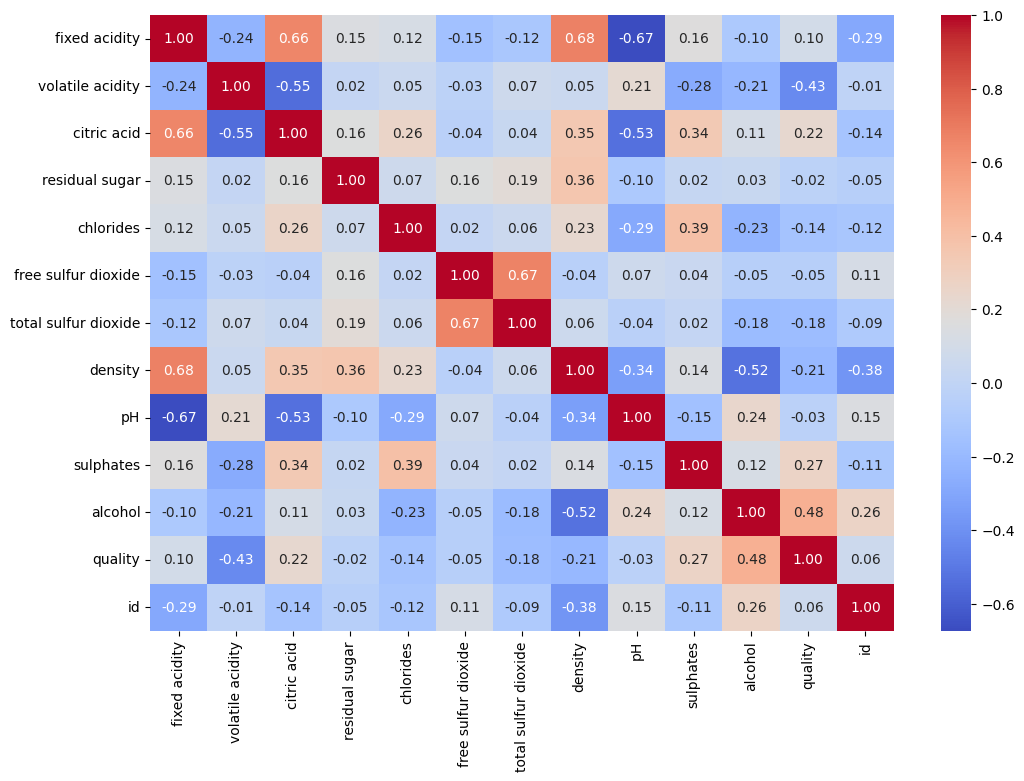

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación
correlation_matrix = trn.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='root_mean_squared_error')
grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')

InvalidParameterError: The 'scoring' parameter of GridSearchCV must be a str among {'f1_macro', 'neg_median_absolute_error', 'normalized_mutual_info_score', 'jaccard', 'v_measure_score', 'precision', 'fowlkes_mallows_score', 'matthews_corrcoef', 'mutual_info_score', 'recall_micro', 'accuracy', 'recall_samples', 'recall_weighted', 'roc_auc_ovo_weighted', 'd2_absolute_error_score', 'neg_negative_likelihood_ratio', 'roc_auc', 'rand_score', 'f1', 'positive_likelihood_ratio', 'average_precision', 'adjusted_rand_score', 'neg_brier_score', 'neg_mean_absolute_error', 'jaccard_macro', 'explained_variance', 'balanced_accuracy', 'neg_mean_poisson_deviance', 'jaccard_micro', 'neg_root_mean_squared_log_error', 'precision_samples', 'recall_macro', 'neg_mean_gamma_deviance', 'recall', 'roc_auc_ovr_weighted', 'neg_max_error', 'r2', 'neg_root_mean_squared_error', 'top_k_accuracy', 'completeness_score', 'f1_samples', 'jaccard_weighted', 'neg_mean_squared_log_error', 'roc_auc_ovr', 'f1_micro', 'precision